# (13) dec sigma, dt — fixed

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/16 * t_train

cfg_vae['fit_sigma'] = False
cfg_vae['fit_dt'] = False

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-16_b-4_kms-(512,1,1)_<ngd|lin>
b200-ep300-lr(0.001)_temp(0.05)_gr(200)_(2025_08_13,16:53)

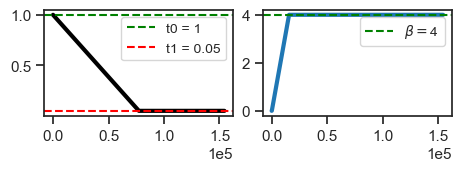

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 1, 1), input_sz=(1, 16, 16), temp=1)

In [8]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 16, 'kl_beta': 4.0, 'latent_channels': 512, 
'latent_pixels': 1, 'latent_stride': 1, 'enc_type': 'ngd', 'dec_type': 'lin', 'recon_mode': 'mse', 'dataset': 
'vH16-wht', 'dataset_name': 'vH16-wht', 'feeder': 'stationary', 'feeder_cfg': {}, 'input_sz': (1, 16, 16), 
'latent_sz': (512, 1, 1), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (7.0,), 'du': (5.0,), 
'dec': 3.45}, 'stochastic': True, 'optim_sigma': False, 'fit_sigma': False, 'fit_prior': True, 'fit_dt': False, 
'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 
'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_vH16-wht_t-16_b-4_kms-(512,1,1)_<ngd|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_vH16-wht_t-16_b-4_kms-(512,1,1)_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}

{'lr': 0.001, 'epochs': 300, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

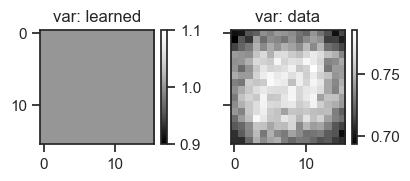

In [9]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_sigma) ** 2).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (4.2, 1.7), sharex='all', sharey='all')
im = axes[0].imshow(var_learned.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
# lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
# print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

In [10]:
tr.train('sigma+dt:fixed')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 300, avg loss: 84.347: 100%|████████| 300/300 [3:18:19<00:00, 39.67s/it]


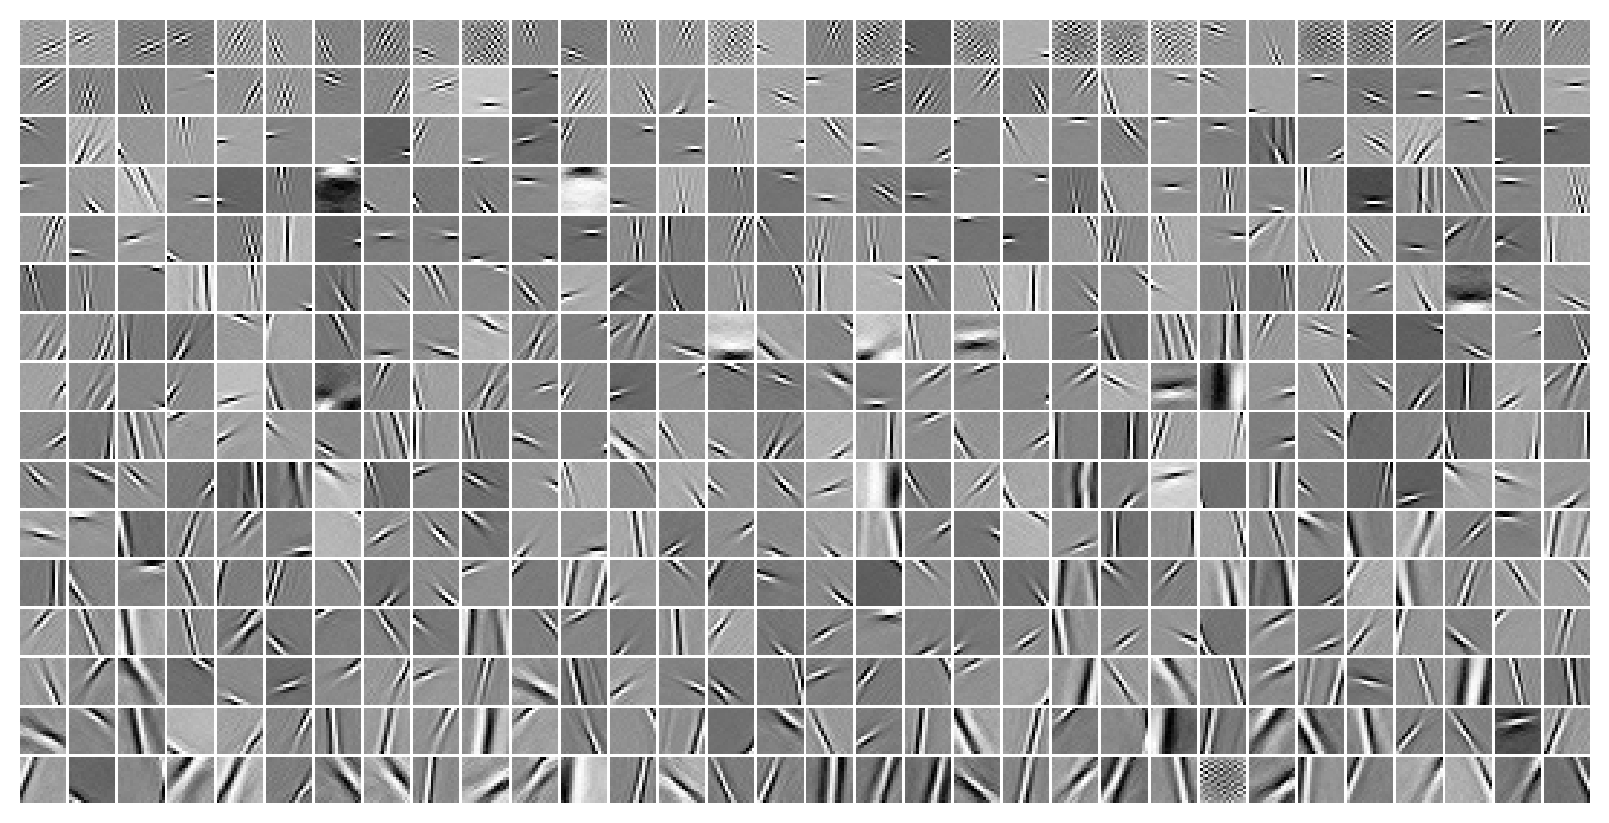

In [19]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████████| 5/5 [00:10<00:00,  2.05s/it]


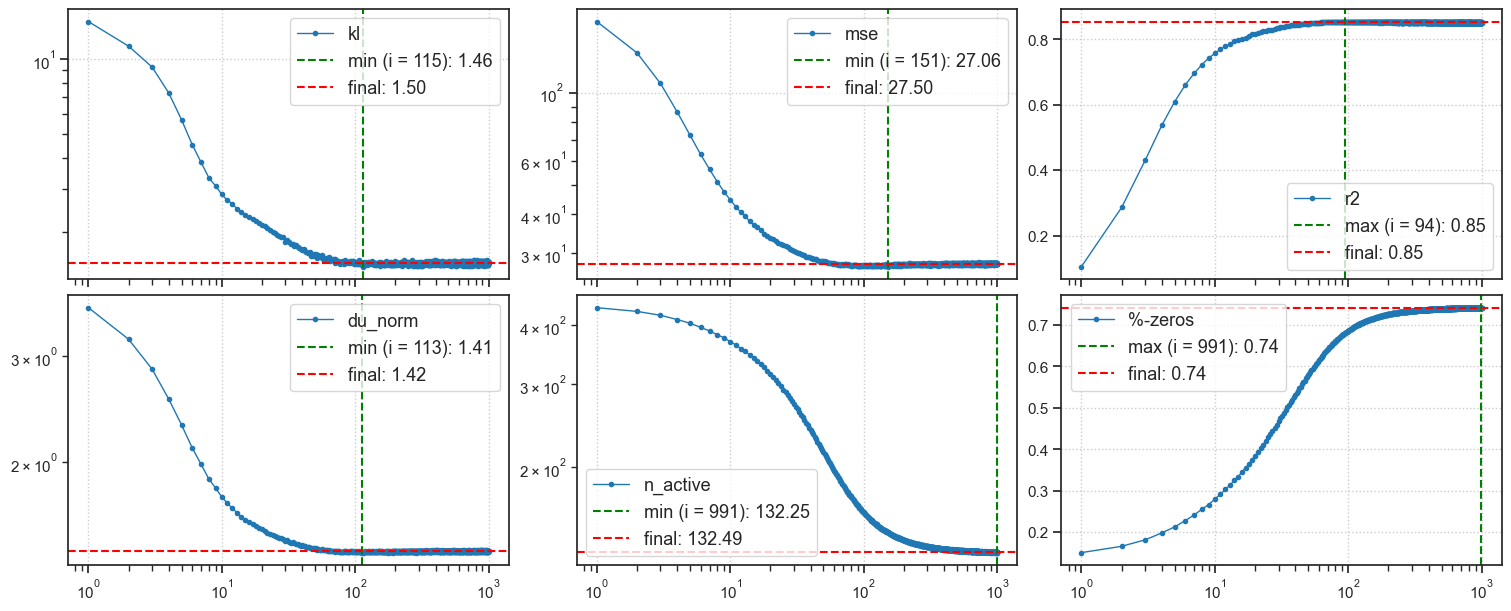

CPU times: user 11.3 s, sys: 16 ms, total: 11.4 s
Wall time: 11.4 s


In [11]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

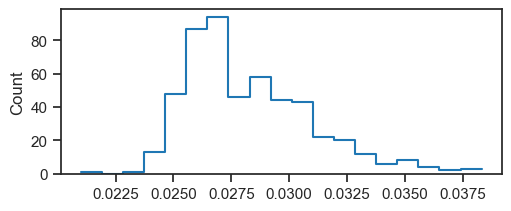

In [21]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)

fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

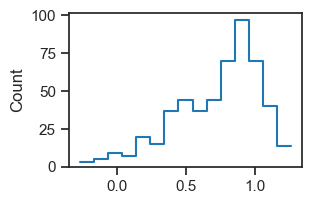

In [22]:
histplot(u0.ravel())
plt.show()

In [23]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.9131356420265008, pvalue=6.870984803254123e-201)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']